In [1]:
import numpy as np
import os
import xarray as xr
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pygmsh
import gmsh
import capytaine as cpt
from scipy.io import loadmat

import wecopttool as wot

In [2]:
# Frequency object
wavefreq    = 1/2.61 # Hz
f1          = wavefreq
nfreq       = 10
freq        = wot.frequency(f1, nfreq, False) # False -> no zero frequency

# Define waves object
amplitude   = 0.0005 # m
phase       = 0 # degrees
wavedir     = 0 # degrees
waves       = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

In [3]:
# platform is a rectangle with cg at -0.46 and 1.44 m long, 0.76 m wide
flapThicknessBottom = 0.04
flapThicknessTop    = 0.1
flapCenterDistanceApart = 1.44
flapWidth   = 0.76
flapHeight = 0.58
flapDraft  = 0.59 # 0.53 is based on matching impedance, 0.59 for fully submerged
cgHeightAboveHinge = 0.17
flap1CG     = [-flapCenterDistanceApart/2, 0, -flapDraft+cgHeightAboveHinge] # from water surface/origin
flap2CG     = [flapCenterDistanceApart/2, 0, -flapDraft+cgHeightAboveHinge] # from water surface/origin

platformFrameLength      = 1.44 
platformFrameThickness = 0.05
platformFrameWidth = 1.06
platformFrameTopDepth = 0.53 + 0.1
platformCG      = [0, 0, -0.8]
cutoutWidth         = platformFrameWidth - 2*platformFrameThickness
cutoutLength        = platformFrameLength - 2*platformFrameThickness

fullWidth = 1.63
columnsRadius       = 0.1
columnsDraft        = 0.53 + 0.1 + 0.4
columnsXY           = [flapCenterDistanceApart/2, fullWidth/2-columnsRadius]

daqLength = 0.72
daqWidth = 0.6
daqHeight = 0.2
daqTopDepth = 0.53 + 0.1 + 0.05

#%% Define the meshes
# Define the meshes
with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', 0.3)
    platform = geom.add_box([-platformFrameLength/2, -platformFrameWidth/2, -platformFrameTopDepth-platformFrameThickness], [platformFrameLength,platformFrameWidth,platformFrameThickness])
    cutout = geom.add_box([-cutoutLength/2, -cutoutWidth/2, -platformFrameTopDepth-platformFrameThickness], [cutoutLength,cutoutWidth,platformFrameThickness])
    cyl1 = geom.add_cylinder([-columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl2 = geom.add_cylinder([-columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl3 = geom.add_cylinder([columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl4 = geom.add_cylinder([columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    DAQ = geom.add_box([-daqLength/2, -daqWidth/2, -daqTopDepth-daqHeight], [daqLength,daqWidth,daqHeight])
    platformFrame = geom.boolean_difference(platform,cutout)
    geom.boolean_union([platformFrame,DAQ,cyl1,cyl2,cyl3,cyl4])
    platformMesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap1 = geom.add_polygon(
            [[-flapCenterDistanceApart/2 - flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [-flapCenterDistanceApart/2 + flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [-flapCenterDistanceApart/2 + flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
            [-flapCenterDistanceApart/2 - flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
    geom.extrude(flap1,[0,flapWidth,0])
    flap1Mesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap2 = geom.add_polygon(
            [[flapCenterDistanceApart/2 - flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapCenterDistanceApart/2 + flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapCenterDistanceApart/2 + flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
            [flapCenterDistanceApart/2 - flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
    geom.extrude(flap2,[0,flapWidth,0])
    flap2Mesh = geom.generate_mesh()


# define the floating body
m1 = 189.8
J1 = 30
# platform = cpt.FloatingBody(mesh=platformMesh, name=f'platform')
platform = cpt.FloatingBody(mesh=platformMesh, name=f'platform', center_of_mass=platformCG)
platform.add_all_rigid_body_dofs()
platform.rotation_center = platform.center_of_mass
# platform.inertia_matrix = platform.compute_rigid_body_inertia()
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([m1,m1,m1,J1,J1,J1]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(platform.dofs),
                                    'radiating_dof': list(platform.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
platform.inertia_matrix = rigid_inertia_matrix_xr
platform.hydrostatic_stiffness = platform.immersed_part().compute_hydrostatic_stiffness()

# define the floating body
flap1 = cpt.FloatingBody(mesh=flap1Mesh, name=f'flap1', center_of_mass=flap1CG)
flap1.add_all_rigid_body_dofs()
#flap1.show_matplotlib()
flap1.rotation_center = flap1.center_of_mass
m2 = 23.1
J2 = 1.19
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([m2,m2,m2,J2,J2,J2]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap1.dofs),
                                    'radiating_dof': list(flap1.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap1.inertia_matrix = rigid_inertia_matrix_xr
flap1.hydrostatic_stiffness = flap1.immersed_part().compute_hydrostatic_stiffness()

# define the floating body
flap2 = cpt.FloatingBody(mesh=flap2Mesh, name=f'flap2', center_of_mass=flap2CG)
flap2.add_all_rigid_body_dofs()
flap2.rotation_center = flap2.center_of_mass
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([m2,m2,m2,J2,J2,J2]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap2.dofs),
                                    'radiating_dof': list(flap2.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap2.inertia_matrix = rigid_inertia_matrix_xr
flap2.hydrostatic_stiffness = flap2.immersed_part().compute_hydrostatic_stiffness()

In [4]:
# run BEM calculations
bem_data_file = 'foswec_WOT_2.61.nc'

if os.path.exists(bem_data_file):
    bem_data = wot.read_netcdf(bem_data_file)
else:
    bem_data = wot.run_bem(platform+flap1+flap2, freq, depth=2)
    bem_data['radiating_dof'] = bem_data['radiating_dof'].astype(str)
    bem_data['influenced_dof'] = bem_data['influenced_dof'].astype(str)
    wot.write_netcdf(bem_data_file, bem_data) # saves BEM data to file

body_coord = bem_data.coords["body_name"].values
com = np.vstack([b.center_of_mass for b in [platform, flap1, flap2]])
cob = np.vstack([b.center_of_buoyancy for b in [platform, flap1, flap2]])
volumes = np.array([b.immersed_part().volume for b in [platform, flap1, flap2]], dtype=float)

bem_data["center_of_mass"] = xr.DataArray(com, dims=("bod","xyz"), coords={"body": body_coord, "xyz": ["x","y","z"]},attrs={"units": "m"})
bem_data["center_of_buoyancy"] = xr.DataArray(cob, dims=("bod","xyz"), coords={"body": body_coord, "xyz": ["x","y","z"]},attrs={"units": "m"})
bem_data["volume"] = xr.DataArray(volumes, dims=("bod",), coords={"body": body_coord}, attrs={"units": "m^3"})

[17:19:21] WARNING  Using the geometric centroid as the center of gravity (COG).

           WARNING  Using the center of gravity (COG) as the rotation center for hydrostatics. Note that the       
                    hydrostatics do not use the axes defined by the FloatingBody degrees of freedom, and the       
                    rotation center should be set manually when using Capytaine to calculate hydrostatics about an 
                    axis other than the COG.

The resolution of the mesh might be insufficient for omega ranging from 12.037 to 24.074.
This warning appears when the largest panel of this mesh has radius > wavelength/8.


[17:19:22] WARNING  Mesh resolution for 114 problems:                                                              
                    The resolution of the mesh might be insufficient for omega ranging from 12.037 to 24.074.      
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

Irregular frequencies might be encountered for omega ranging from 16.851 to 24.074.
Setting a lid for the floating body is recommended.


           WARNING  Irregular frequencies for 76 problems:                                                         
                    Irregular frequencies might be encountered for omega ranging from 16.851 to 24.074.            
                    Setting a lid for the floating body is recommended.

Output()

In [5]:
import FOSWEC_M4E_inputs

# create multibody system for wavebot using M4E
m0 = [m1, m2, m2]
J0 = [J1, J2, J2]

# return the reduced coordinate matrices
impedance_reduced, excitation_reduced, hydrostatic_stiffness_reduced, R0, M4E_ndof = wot.utilities.setup_from_M4E(FOSWEC_M4E_inputs, bem_data, [platform, flap1, flap2], m0, J0)

Table validation successful:	 No errors found.
Forces validation successful:	 No errors found.
Points validation successful:	 No errors found.


Bodies and joints table:
 Joint Connected Bodies Joint Type                         ParentCGtoJoint         JointtoChildCG Prismatic Direction
     1              0 1          F                 [0, -0.800000000000000]               NaN  NaN            NaN  NaN
     2              1 2          R [-0.720000000000000, 0.210000000000000] [0, 0.170000000000000]            NaN  NaN
     3              1 3          R  [0.720000000000000, 0.210000000000000] [0, 0.170000000000000]            NaN  NaN

Points table:
Empty DataFrame
Columns: [Body, PointType, PointID, Rel coordinates]
Index: []

Forces table:
Empty DataFrame
Columns: [ForceType, BodiesConnected, PointType, PointID, ForceComponents, SpringParameters, DamperParameters]
Index: []

The variables that require initial conditions, in this order, are:
[X_1, Z_1, Theta_1, Theta_2, Theta_3, XD_1, 

In [6]:


# add forces to stabilize system
mooring_stiffness_full = np.diag([8e3, 2e5, 2e5, 0, 0, 0, 0, 0, 0])
mooring_stiffness = wot.utilities.reduce_damping_stiffness_M4E(mooring_stiffness_full, R0)

mooring_damping_full = np.diag([8e2, 1e4, 1e4, 0, 0, 0, 0, 0, 0])
mooring_damping = wot.utilities.reduce_damping_stiffness_M4E(mooring_damping_full, R0)

flap_linear_damping_full = np.diag([0, 0, 0, 0, 0, 10, 0, 0, 10])
flap_linear_damping = wot.utilities.reduce_damping_stiffness_M4E(flap_linear_damping_full, R0)

#########################################
# Solve using wec opt tool

def f_mooring(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat,pos)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)

    mooring = -pos @ mooring_stiffness - vel @ mooring_damping
    mooring_force = jnp.dot(time_matrix,mooring)
    return mooring_force

def f_linear_damping(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat,pos)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)

    damping = - vel @ flap_linear_damping
    linear_damping_force = jnp.dot(time_matrix, damping)
    return linear_damping_force

# WecOptTool does not take gravity into account and assumes equilibrium so no pretension needed
f_add = {'f_mooring': f_mooring, 'f_linear_damping': f_linear_damping} # 

# Define and solve the WOT object
wec = wot.WEC.from_impedance(
    waves.freq.values,
    impedance=impedance_reduced,
    exc_coeff=excitation_reduced,
    hydrostatic_stiffness=hydrostatic_stiffness_reduced,
    constraints=None,
    f_add=f_add,
)

# Objective function
obj_fun = lambda wec, x_wec, x_opt, waves : 0
nstate_opt = 0

# Solve
scale_x_wec = 1e1
scale_x_opt = 1e-3
scale_obj = 1e-2

results = wec.solve(
    waves,
    obj_fun,
    nstate_opt,
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
)

#%% Plot results
nsubsteps = 40
wec_fdom_full, wec_tdom_full = wot.utilities.post_process_M4E(wec, results, waves, nsubsteps, R0)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 2
            Gradient evaluations: 1


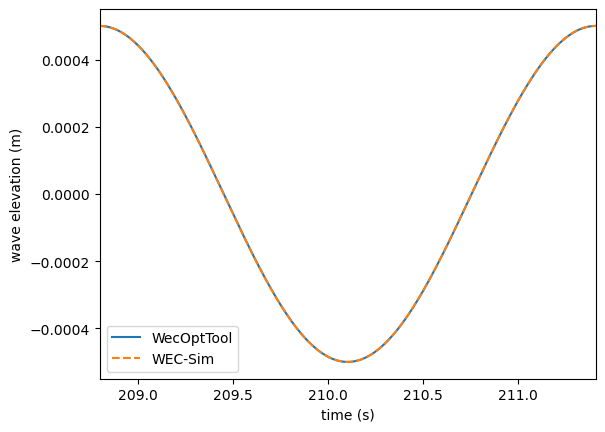

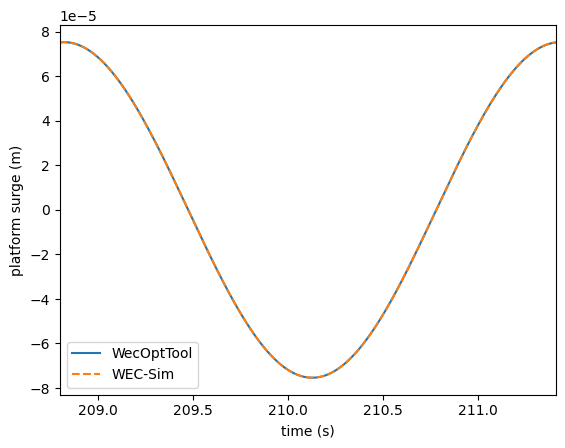

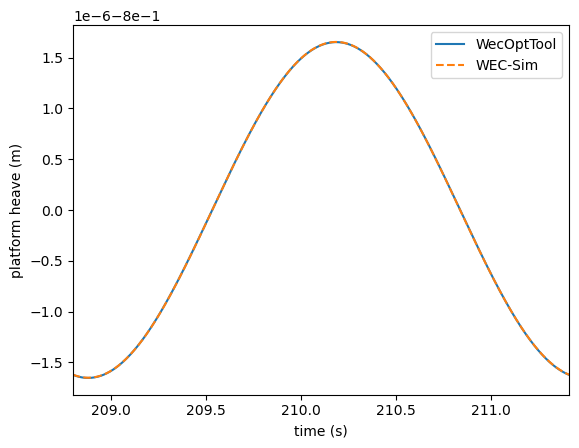

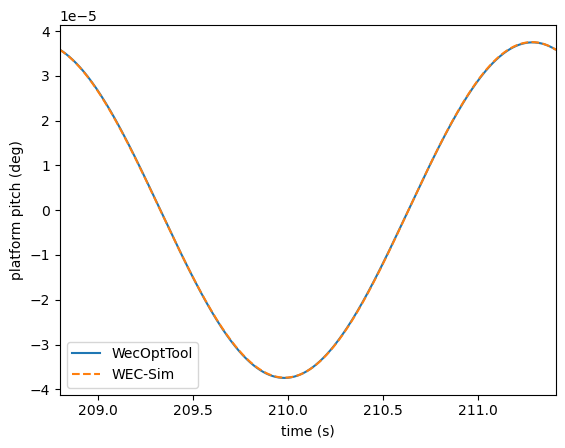

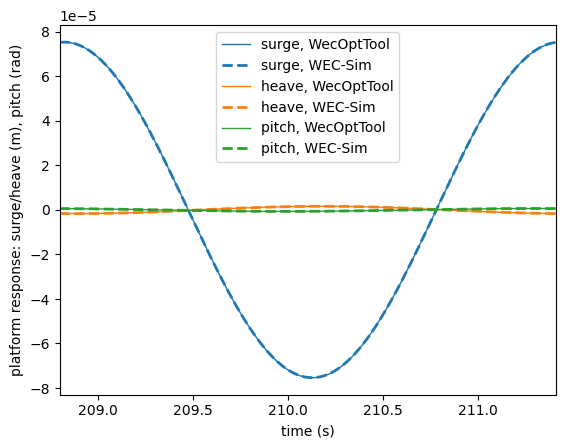

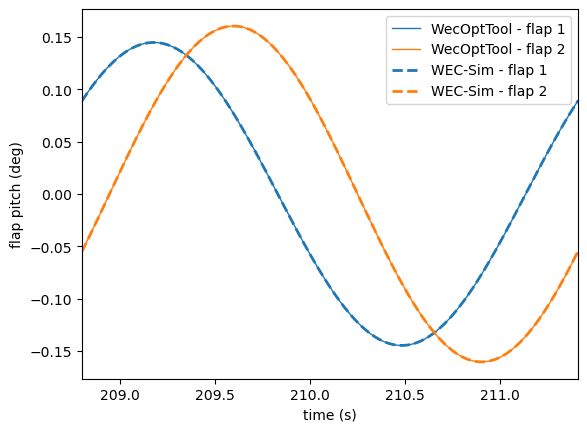

In [10]:
# load in WEC-Sim results for comparison

ws_path = 'WEC-Sim'
ws_output = loadmat(os.path.join(ws_path,'WSoutput_261_001.mat'), struct_as_record=False, squeeze_me=True)

phase_offset_time = 208.8

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, np.squeeze(wec_tdom_full.sel(realization=0)['wave_elev']), label='WecOptTool')
plt.plot(ws_output['time'], ws_output['waveElev'], '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('wave elevation (m)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[0,:], label='WecOptTool')
plt.plot(ws_output['time'], ws_output['platformResponse'][:,0], '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('platform surge (m)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[1,:]+platformCG[2], label='WecOptTool')
plt.plot(ws_output['time'], ws_output['platformResponse'][:,2], '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('platform heave (m)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[2,:]*180/np.pi, label='WecOptTool')
plt.plot(ws_output['time'], ws_output['platformResponse'][:,4]*180/np.pi, '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('platform pitch (deg)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()
 
plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time,
         wec_tdom_full.sel(realization=0).pos[0,:],
         'C0-',linewidth=1, label='surge, WecOptTool')
plt.plot(ws_output['time'],
         ws_output['platformResponse'][:,0],
         'C0--',linewidth=2, label='surge, WEC-Sim')
plt.plot(wec_tdom_full['time']+phase_offset_time,
         wec_tdom_full.sel(realization=0).pos[1,:],
         'C1-',linewidth=1, label='heave, WecOptTool')
plt.plot(ws_output['time'],
         ws_output['platformResponse'][:,2]-platformCG[2],
         'C1--',linewidth=2, label='heave, WEC-Sim')
plt.plot(wec_tdom_full['time']+phase_offset_time,
         wec_tdom_full.sel(realization=0).pos[2,:],
         'C2-',linewidth=1, label='pitch, WecOptTool')
plt.plot(ws_output['time'],
         ws_output['platformResponse'][:,4],
         'C2--',linewidth=2, label='pitch, WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('platform response: surge/heave (m), pitch (rad)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[5,:]*180/np.pi, color='C0',linewidth=1, label='WecOptTool - flap 1')
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[8,:]*180/np.pi, color='C1',linewidth=1, label='WecOptTool - flap 2')
plt.plot(ws_output['time'], ws_output['pto1Response'][:,4]*180/np.pi, '--', color='C0',linewidth=2, label='WEC-Sim - flap 1')
plt.plot(ws_output['time'], ws_output['pto2Response'][:,4]*180/np.pi, '--', color='C1',linewidth=2, label='WEC-Sim - flap 2')
plt.xlabel('time (s)')
plt.ylabel('flap pitch (deg)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

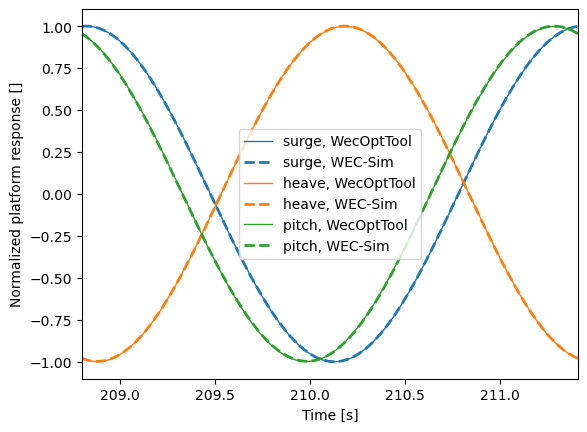

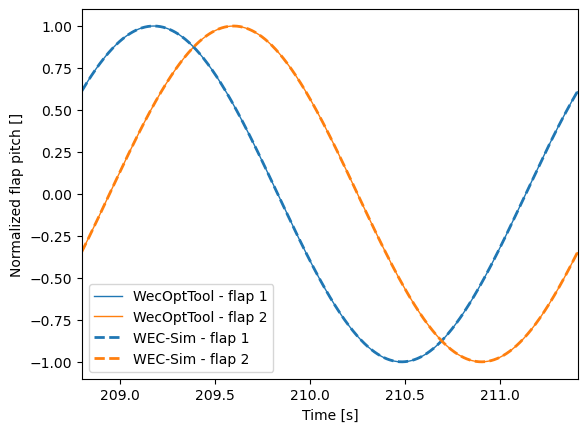

In [ ]:
ws_mask = ((ws_output['time'] >= phase_offset_time) &
           (ws_output['time'] <= phase_offset_time + 1/wavefreq))

surge_ref = np.max(np.abs(ws_output['platformResponse'][ws_mask,0]))
heave_ref = np.max(np.abs(ws_output['platformResponse'][ws_mask,2]-platformCG[2]))
pitch_ref = np.max(np.abs(ws_output['platformResponse'][ws_mask,4]))
flap1_ref = np.max(np.abs(ws_output['pto1Response'][ws_mask,4]))
flap2_ref = np.max(np.abs(ws_output['pto2Response'][ws_mask,4]))

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time,
         wec_tdom_full.sel(realization=0).pos[0,:] / surge_ref,
         'C0-',linewidth=1, label='surge, WecOptTool')
plt.plot(ws_output['time'],
         ws_output['platformResponse'][:,0] / surge_ref,
         'C0--',linewidth=2, label='surge, WEC-Sim')
plt.plot(wec_tdom_full['time']+phase_offset_time,
         wec_tdom_full.sel(realization=0).pos[1,:] / heave_ref,
         'C1-',linewidth=1, label='heave, WecOptTool')
plt.plot(ws_output['time'],
         (ws_output['platformResponse'][:,2]-platformCG[2]) / heave_ref,
         'C1--',linewidth=2, label='heave, WEC-Sim')
plt.plot(wec_tdom_full['time']+phase_offset_time,
         wec_tdom_full.sel(realization=0).pos[2,:] / pitch_ref,
         'C2-',linewidth=1, label='pitch, WecOptTool')
plt.plot(ws_output['time'],
         ws_output['platformResponse'][:,4] / pitch_ref,
         'C2--',linewidth=2, label='pitch, WEC-Sim')
plt.xlabel('Time [s]')
plt.ylabel('Normalized platform response []')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

#plt.savefig(
#    "platform_ver.pdf",
#    format="pdf",
#    bbox_inches="tight",
#)

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[5,:] / flap1_ref, color='C0',linewidth=1, label='WecOptTool - flap 1')
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[8,:] / flap2_ref, color='C1',linewidth=1, label='WecOptTool - flap 2')
plt.plot(ws_output['time'], ws_output['pto1Response'][:,4] / flap1_ref, '--', color='C0',linewidth=2, label='WEC-Sim - flap 1')
plt.plot(ws_output['time'], ws_output['pto2Response'][:,4] / flap2_ref, '--', color='C1',linewidth=2, label='WEC-Sim - flap 2')
plt.xlabel('Time [s]')
plt.ylabel('Normalized flap pitch []')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

#plt.savefig(
#    "flap_ver.pdf",
#    format="pdf",
#    bbox_inches="tight",
#)

In [9]:
def rmse_over_timerange(t_std, y_std, t_cmp, y_cmp, t0, t1):
    """
    WEC-Sim is the standard: (t_std, y_std).
    Interpolate WecOptTool (t_cmp, y_cmp) onto t_std, then compute RMSE on [t0, t1].
    """
    t_std = np.asarray(t_std)
    y_std = np.asarray(y_std)
    t_cmp = np.asarray(t_cmp)
    y_cmp = np.asarray(y_cmp)

    mask = (t_std >= t0) & (t_std <= t1)
    tt = t_std[mask]
    y_true = y_std[mask]

    y_pred = np.interp(tt, t_cmp, y_cmp)
    max_ref                 = np.max(np.abs(y_true), axis=0) # Normalization factors from Gonzalez 2006
    #rel_L2_per_DOF          = np.abs(y_pred - y_true) / max_ref
    #NRMSE_per_DOF  = np.linalg.norm(rel_L2_per_DOF / len(tt), axis=0)
    #NRMSE_per_body          = np.linalg.norm(NRMSE_per_body_per_DOF,axis=-1)
    NRMSE_per_DOF = np.sqrt(np.mean(((y_pred - y_true) / max_ref) ** 2, axis=0))
    return NRMSE_per_DOF #np.sqrt(np.mean((y_pred - y_true)**2))

# time window (same as your plots)
t0 = phase_offset_time
t1 = phase_offset_time + 1/wavefreq - (wec_tdom_full["time"].values[1] - wec_tdom_full["time"].values[0]) # subtract one time step to avoid extrapolation in interpolation step below

# time vectors
t_ws  = ws_output["time"]                       # standard
t_wot = wec_tdom_full["time"] + phase_offset_time    # compared dataset (shifted like your plots)

# define the 5 comparisons: (name, WEC-Sim signal, WecOptTool signal)
comparisons = [
    ("platform surge",
     ws_output["platformResponse"][:, 0],
     wec_tdom_full.sel(realization=0).pos[0,:]),

    ("platform heave",
     ws_output["platformResponse"][:, 2],
     wec_tdom_full.sel(realization=0).pos[1,:] + platformCG[2]),

    ("platform pitch",
     ws_output["platformResponse"][:, 4] * 180/np.pi,
     wec_tdom_full.sel(realization=0).pos[2,:] * 180/np.pi),

    ("flap 1 pitch",
     ws_output["pto1Response"][:, 4] * 180/np.pi,
     wec_tdom_full.sel(realization=0).pos[5,:] * 180/np.pi),

    ("flap 2 pitch",
     ws_output["pto2Response"][:, 4] * 180/np.pi,
     wec_tdom_full.sel(realization=0).pos[8,:] * 180/np.pi),
]

# compute RMSEs (pure numpy)
names = [c[0] for c in comparisons]
rmses = np.array([
    rmse_over_timerange(t_ws, y_ws, t_wot, y_wot, t0, t1)
    for (_, y_ws, y_wot) in comparisons
])

# Option A: simple "table" as a dict of numpy arrays (no pandas)
rmse_table = {"variable": np.array(names, dtype=object), "nrmse": rmses}
print("Normalized RMSE (%) over [{:.6g}, {:.6g}] s".format(t0, t1))
for n, e in zip(rmse_table["variable"], 100*rmse_table["nrmse"]):
    print(f"{n:22s}  {e:.6g}")


Normalized RMSE (%) over [208.8, 211.407] s
platform surge          0.0199336
platform heave          1.68739e-07
platform pitch          0.222572
flap 1 pitch            0.018907
flap 2 pitch            0.0168029
